In [1]:
import pandas as pd
import utils as uti

In [2]:
df = pd.read_pickle("../data/01_df_train.pkl")

In [3]:
import pickle
from pathlib import Path

models_file_path = Path("../data/02_dic_models.pkl")

if models_file_path.exists():
    print('loading model file')
    with models_file_path.open("rb") as file:
        models = pickle.load(file)
else:
    print('creating new model file')
    models = {}

creating new model file


# param optimization

In [4]:
walds = pd.read_pickle("../data/01_df_walds.pkl")
walds.head()

,var,wald,corr,corr ind
0,checking_account_status_woe,81.374162,0.243345,False
1,duration_months_woe,40.639132,0.23402,False
2,credit_history_woe,40.399187,0.376188,True
3,savings_account_bonds_woe,30.802473,0.243345,False
4,credit_amount_woe,28.469128,0.23402,False


## load info from previous steps

In [5]:
event = 'bad'

In [6]:
X = df[walds['var'].tolist()]
y = df[event]

In [7]:
import numpy as np
import optuna
import xgboost as xgb

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score


def objective(trial):
    params = params = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "tree_method": "hist",

    # Let early stopping determine the final number of trees
    "n_estimators": 5000,

    "max_depth": trial.suggest_int(
        "max_depth", 2, 8
    ),

    "learning_rate": trial.suggest_float(
        "learning_rate", 0.01, 0.15, log=True
    ),

    "min_child_weight": trial.suggest_float(
        "min_child_weight", 1, 30, log=True
    ),

    "subsample": trial.suggest_float(
        "subsample", 0.7, 1.0
    ),

    "colsample_bytree": trial.suggest_float(
        "colsample_bytree", 0.7, 1.0
    ),

    "gamma": trial.suggest_float(
        "gamma", 1e-8, 10, log=True
    ),

    "reg_alpha": trial.suggest_float(
        "reg_alpha", 1e-8, 10, log=True
    ),

    "reg_lambda": trial.suggest_float(
        "reg_lambda", 0.1, 100, log=True
    ),

    # Additional useful controls
    "max_delta_step": trial.suggest_float(
        "max_delta_step", 0, 5
    ),

    "max_bin": trial.suggest_int(
        "max_bin", 128, 512
    ),

    "random_state": 42,
    "n_jobs": -1,
    "early_stopping_rounds": 100,
}

    
    # {
    #     "objective": "binary:logistic",
    #     "eval_metric": "aucpr",
    #     "tree_method": "hist",

    #     # "n_estimators": trial.suggest_int(
    #     #     "n_estimators", 200, 2000
    #     # ),

    #     # Large upper limit; early stopping determines the useful number
    #     "n_estimators": 5000,
        
    #     "max_depth": trial.suggest_int(
    #         "max_depth", 2, 10
    #     ),
    #     "learning_rate": trial.suggest_float(
    #         "learning_rate", 0.005, 0.2, log=True
    #     ),
    #     "min_child_weight": trial.suggest_float(
    #         "min_child_weight", 1, 20, log=True
    #     ),
    #     "subsample": trial.suggest_float(
    #         "subsample", 0.6, 1.0
    #     ),
    #     "colsample_bytree": trial.suggest_float(
    #         "colsample_bytree", 0.6, 1.0
    #     ),
    #     "gamma": trial.suggest_float(
    #         "gamma", 0, 10
    #     ),
    #     "reg_alpha": trial.suggest_float(
    #         "reg_alpha", 1e-8, 10, log=True
    #     ),
    #     "reg_lambda": trial.suggest_float(
    #         "reg_lambda", 1e-8, 10, log=True
    #     ),

    #     "random_state": 42,
    #     "n_jobs": -1,
        
    #     "early_stopping_rounds": 100,
    # }

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    fold_pr_aucs = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
        X_train = X.iloc[train_idx]
        X_valid = X.iloc[valid_idx]
        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        model = xgb.XGBClassifier(**params)

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_valid, y_valid)],
            verbose=False
        )

        predictions = model.predict_proba(X_valid)[:, 1]

        # Average precision is commonly used as the PR-AUC summary metric
        pr_auc = average_precision_score(
            y_valid,
            predictions
        )

        fold_pr_aucs.append(pr_auc)

        # Report the mean PR-AUC achieved so far
        trial.report(
            np.mean(fold_pr_aucs),
            step=fold
        )

        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_pr_aucs)

In [8]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=10,
        n_warmup_steps=2
    )
)

study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True
)

print("Best AUC:", study.best_value)
print("Best parameters:")
print(study.best_params)

[I 2026-09-10 20:26:14,780] A new study created in memory with name: no-name-5b7ae170-3464-46a3-a2d5-ca145b6ba2fe


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-09-10 20:26:15,137] Trial 0 finished with value: 0.6590787350892251 and parameters: {'max_depth': 4, 'learning_rate': 0.13125830316209655, 'min_child_weight': 12.057126287443763, 'subsample': 0.8795975452591109, 'colsample_bytree': 0.7468055921327309, 'gamma': 2.5348407664333426e-07, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 39.67605077052987, 'max_delta_step': 3.005575058716044, 'max_bin': 400}. Best is trial 0 with value: 0.6590787350892251.
[I 2026-09-10 20:26:15,361] Trial 1 finished with value: 0.6604895313688894 and parameters: {'max_depth': 2, 'learning_rate': 0.13826189316223852, 'min_child_weight': 16.967533607196547, 'subsample': 0.7637017332034828, 'colsample_bytree': 0.7545474901621302, 'gamma': 4.4734294104626844e-07, 'reg_alpha': 5.472429642032198e-06, 'reg_lambda': 3.752055855124281, 'max_delta_step': 2.1597250932105787, 'max_bin': 240}. Best is trial 1 with value: 0.6604895313688894.
[I 2026-09-10 20:26:15,810] Trial 2 finished with value: 0.64813560946

## optimization summary

In [9]:
import matplotlib.pyplot as plt

In [10]:
from optuna.importance import get_param_importances

importance_dict = get_param_importances(study)

/tmp/ipykernel_1890428/3694072603.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study)


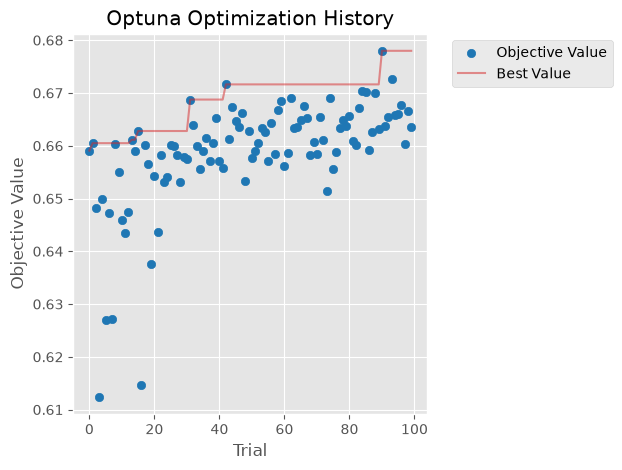

In [11]:
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Optuna Optimization History")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1890428/2144959284.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_param_importances(study)


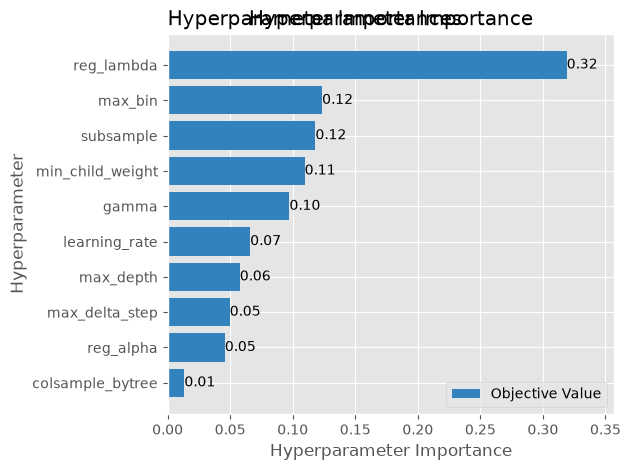

In [12]:
fig = optuna.visualization.matplotlib.plot_param_importances(study)
plt.title("Hyperparameter Importance")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1890428/1725605251.py:1: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_slice(
/tmp/ipykernel_1890428/1725605251.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


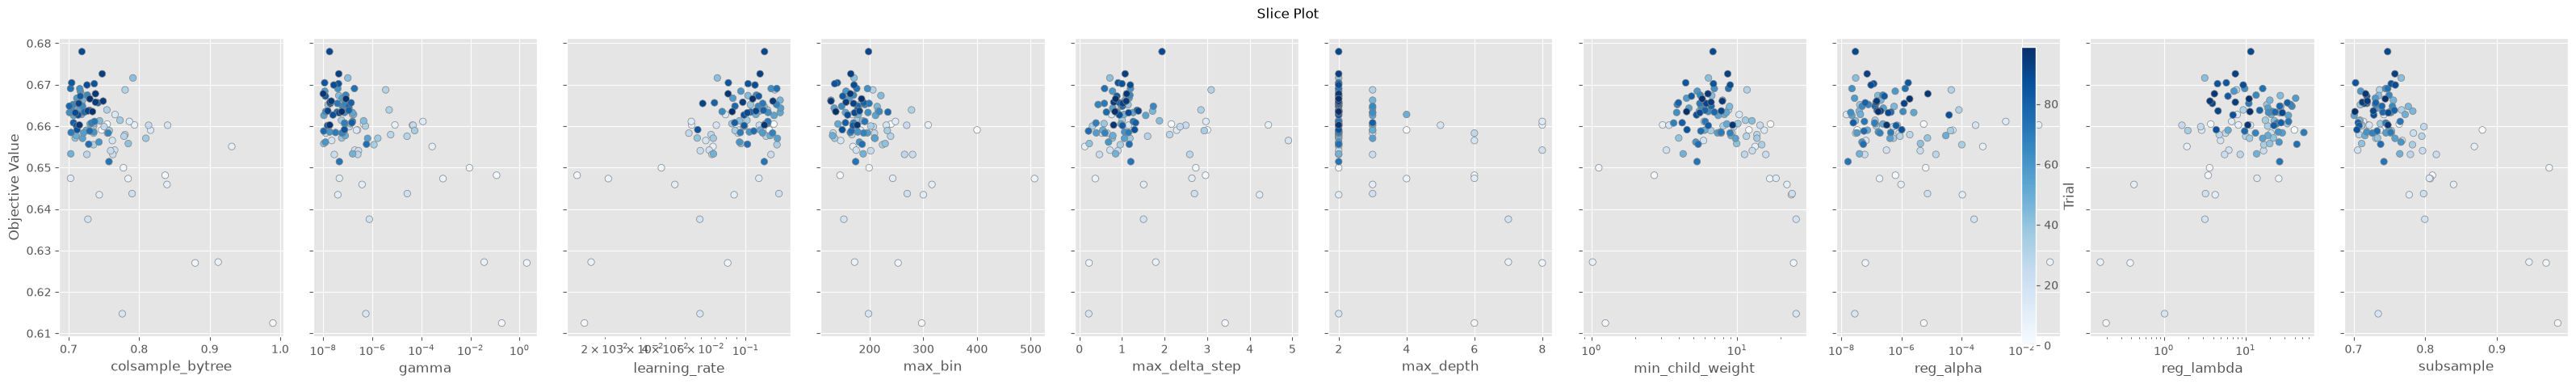

In [13]:
fig = optuna.visualization.matplotlib.plot_slice(
    study,
    params=list(importance_dict.keys())
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1890428/1484866845.py:1: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_parallel_coordinate(


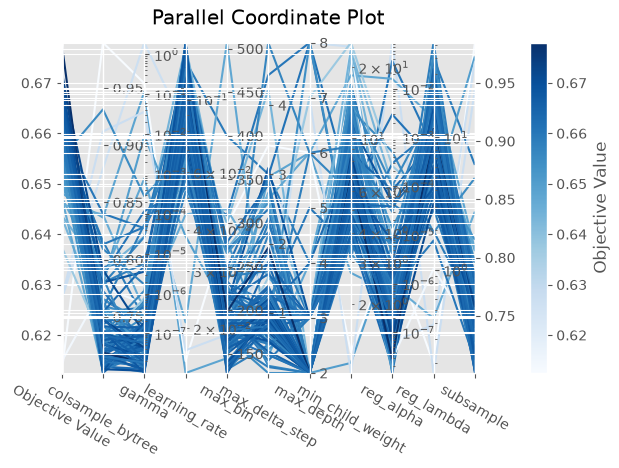

In [14]:
fig = optuna.visualization.matplotlib.plot_parallel_coordinate(
    study,
    params=list(importance_dict.keys())
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1890428/2829545407.py:1: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_contour(


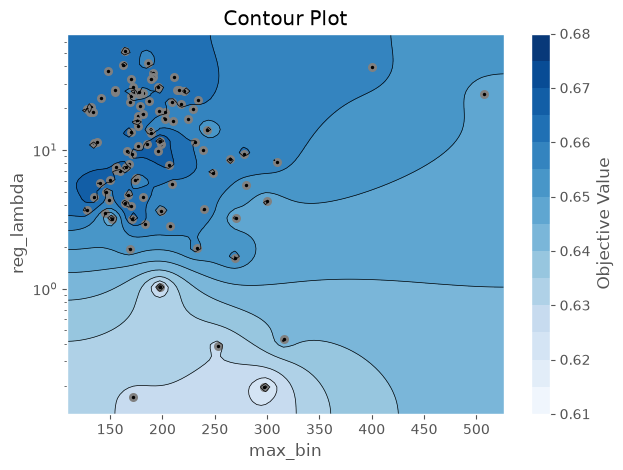

In [15]:
fig = optuna.visualization.matplotlib.plot_contour(
    study,
    params=list(importance_dict.keys())[:2]
)
plt.tight_layout()
plt.show()

In [16]:
trials_df = study.trials_dataframe()

best_trials = (
    trials_df
    .query("state == 'COMPLETE'")
    .sort_values("value", ascending=False)
    .head(10)
)

In [17]:
best_trials

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_bin,params_max_delta_step,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,system_attrs_tpe:relative_params:0,state
90,90,0.677985,2026-09-10 20:26:47.042703,2026-09-10 20:26:47.343041,0 days 00:00:00.300338,0.718736,1.842050e-08,0.124329,198,1.939146,2,6.828022,2.914082e-08,11.594892,0.747501,"{""colsample_bytree"": 0.7187364775547248, ""gamm...",COMPLETE
93,93,0.672623,2026-09-10 20:26:48.049428,2026-09-10 20:26:48.365913,0 days 00:00:00.316485,0.747530,4.381292e-08,0.118072,165,1.073555,2,8.628875,7.156199e-08,7.508123,0.757646,"{""colsample_bytree"": 0.7475303718329318, ""gamm...",COMPLETE
42,42,0.671623,2026-09-10 20:26:29.094246,2026-09-10 20:26:29.444360,0 days 00:00:00.350114,0.791167,1.021993e-07,0.072492,171,0.714523,2,6.360664,2.981532e-08,3.167618,0.766462,"{""colsample_bytree"": 0.7911668700937387, ""gamm...",COMPLETE
84,84,0.670457,2026-09-10 20:26:45.387418,2026-09-10 20:26:45.666906,0 days 00:00:00.279488,0.704258,1.159415e-08,0.082216,140,0.909901,2,4.441041,1.663259e-06,5.815379,0.702785,"{""colsample_bytree"": 0.7042576162130725, ""gamm...",COMPLETE
85,85,0.670227,2026-09-10 20:26:45.668237,2026-09-10 20:26:45.927565,0 days 00:00:00.259328,0.736303,4.267648e-08,0.103000,135,0.999368,2,6.879899,1.181504e-07,4.542050,0.752450,"{""colsample_bytree"": 0.7363026852120558, ""gamm...",COMPLETE
88,88,0.669923,2026-09-10 20:26:46.445488,2026-09-10 20:26:46.704627,0 days 00:00:00.259139,0.725977,2.738948e-08,0.111476,171,1.194888,2,8.961693,9.660352e-08,9.374896,0.758160,"{""colsample_bytree"": 0.7259769403003403, ""gamm...",COMPLETE
74,74,0.669072,2026-09-10 20:26:39.561266,2026-09-10 20:26:39.844135,0 days 00:00:00.282869,0.702639,1.897310e-07,0.142958,176,0.590654,2,8.720979,1.325384e-06,16.234248,0.747583,"{""colsample_bytree"": 0.7026391961854046, ""gamm...",COMPLETE
62,62,0.669054,2026-09-10 20:26:35.597049,2026-09-10 20:26:35.888034,0 days 00:00:00.290985,0.715769,4.007994e-08,0.134137,196,1.199135,2,6.977117,2.238304e-08,9.785687,0.744616,"{""colsample_bytree"": 0.7157687596765686, ""gamm...",COMPLETE
31,31,0.668749,2026-09-10 20:26:25.656406,2026-09-10 20:26:25.877076,0 days 00:00:00.220670,0.780050,3.546285e-06,0.139992,206,3.093111,3,11.698760,4.506915e-05,7.760057,0.736227,"{""colsample_bytree"": 0.7800503331266612, ""gamm...",COMPLETE
59,59,0.668425,2026-09-10 20:26:34.594851,2026-09-10 20:26:34.939401,0 days 00:00:00.344550,0.716443,1.177850e-08,0.094854,156,0.776663,2,5.328033,6.169154e-07,7.218731,0.709926,"{""colsample_bytree"": 0.7164427695350523, ""gamm...",COMPLETE


# fit best model

In [18]:
best_params = {
    **study.best_params,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1,
}

final_model = xgb.XGBClassifier(**best_params)

final_model.fit(X, y, verbose=False)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7187364775547248
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


# partial dependence plots

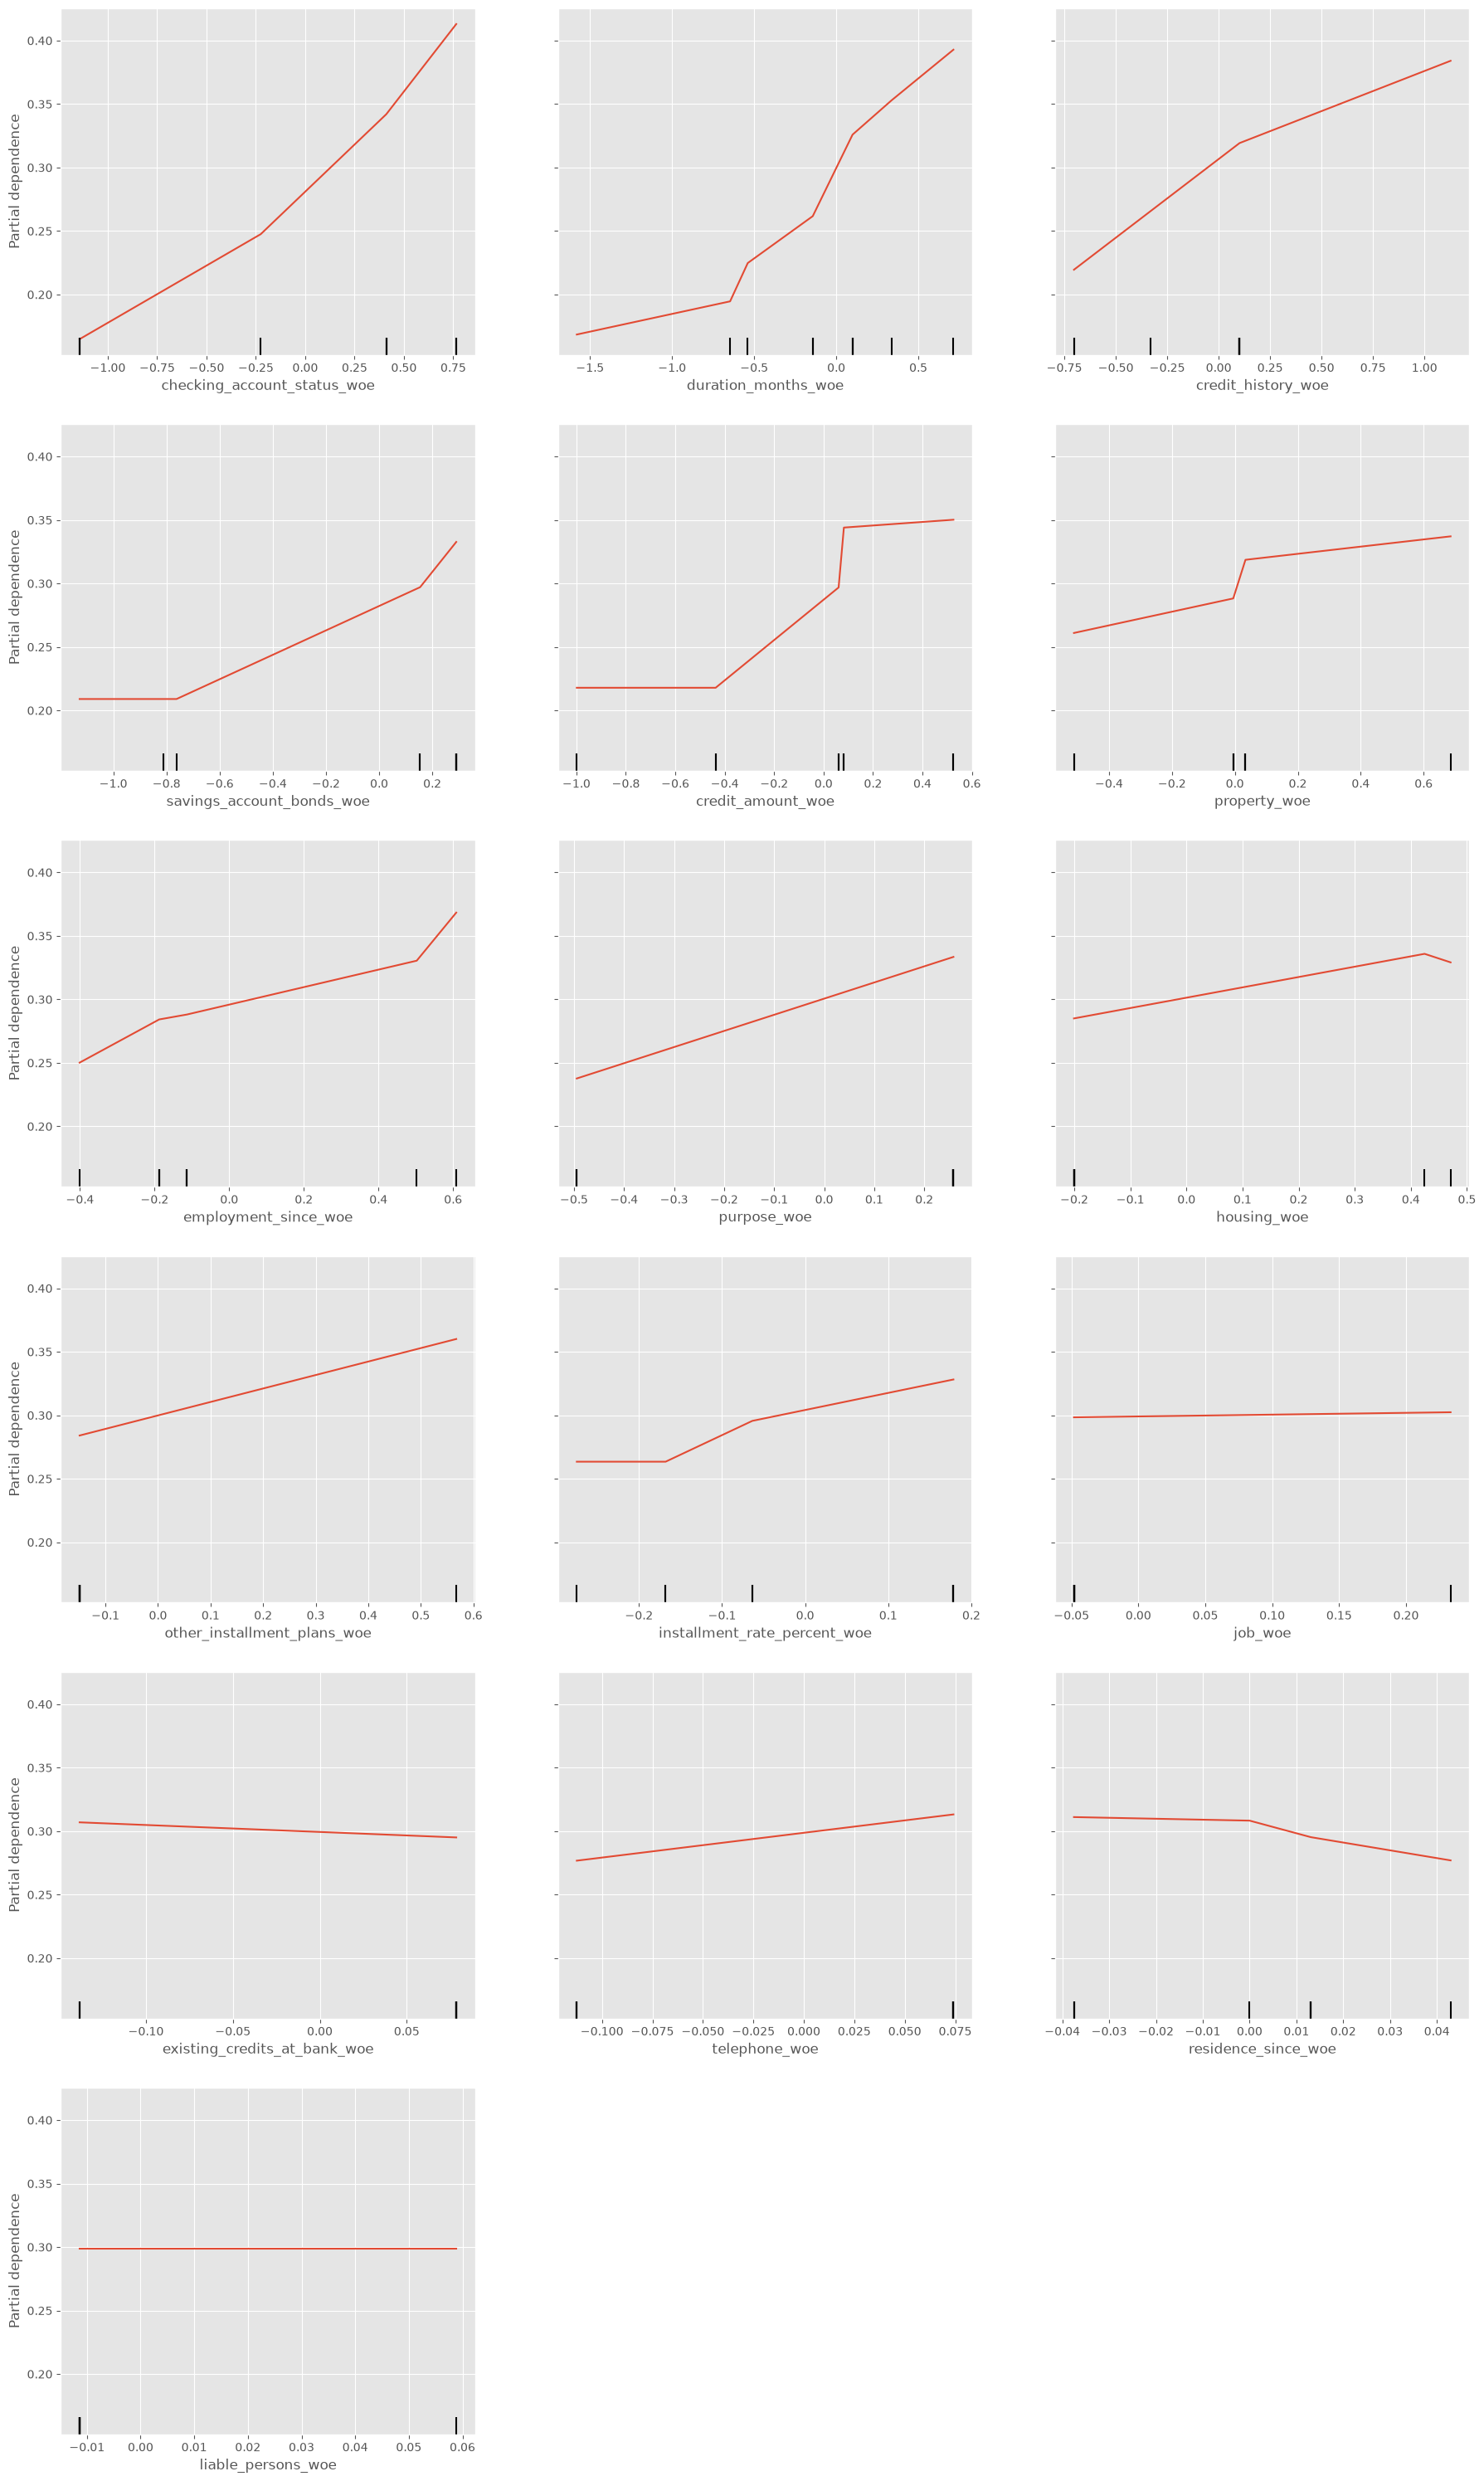

In [19]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

features = walds["var"].tolist()

display = PartialDependenceDisplay.from_estimator(
    final_model,
    X,
    features=features,
    n_cols=3
)

n_rows = (len(features) + 2) // 3

display.figure_.set_size_inches(
    18,
    5 * n_rows
)

display.figure_.tight_layout()

plt.show()

# save models

In [20]:
models['xgb woe'] = final_model

In [21]:
with open(models_file_path, "wb") as file:
    pickle.dump(models, file)